# Esercizi Pandas - NumPy - Matplotlib

## 1. Consumo di alcol per paese

### Esegui un’analisi esplorativa focalizzata sul consumo di alcol. 
### Analizza i seguenti aspetti:

### - Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

### - Calcola la media del consumo di birra, vino, e distillati

### - Crea una nuova colonna alcohol_index che sia: (beer_servings + wine_servings + spirit_servings) / 3

### - Trova il paese con il valore massimo di alcohol_index

### - Filtra solo i paesi che consumano più di 100 birre all’anno

### Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)
### Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df.info()
df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       193 non-null    str    
 1   beer_servings                 193 non-null    int64  
 2   spirit_servings               193 non-null    int64  
 3   wine_servings                 193 non-null    int64  
 4   total_litres_of_pure_alcohol  193 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 9.2 KB


,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
5,Antigua & Barbuda,102,128,45,4.9
6,Argentina,193,25,221,8.3
7,Armenia,21,179,11,3.8
8,Australia,261,72,212,10.4
9,Austria,279,75,191,9.7


In [80]:
# prime 10 elementi in ordine crescente secondo total_liters

ordered = df.sort_values(by="total_litres_of_pure_alcohol", ascending=False)
ordered.head(10)

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
15,Belarus,142,373,42,14.4
98,Lithuania,343,244,56,12.9
3,Andorra,245,138,312,12.4
68,Grenada,199,438,28,11.9
61,France,127,151,370,11.8
45,Czech Republic,361,170,134,11.8
141,Russian Federation,247,326,73,11.5
99,Luxembourg,236,133,271,11.4
155,Slovakia,196,293,116,11.4
81,Ireland,313,118,165,11.4


In [81]:
# media consumo birra, vino e distillati

beer_mean = df["beer_servings"].mean()
wine_mean = df["wine_servings"].mean()
spirit_mean = df["spirit_servings"].mean()

print(f"Beer: {beer_mean} Wine: {wine_mean} Spirit: {spirit_mean}")


Beer: 106.16062176165804 Wine: 49.45077720207254 Spirit: 80.99481865284974


In [82]:
# nuova colonna alcohol_index che sia: (beer_servings + wine_servings + spirit_servings) / 3

df["alcohol_index"] = (df["beer_servings"] + df["wine_servings"] + df["spirit_servings"])/3
df.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
0,Afghanistan,0,0,0,0.0,0.000000
1,Albania,89,132,54,4.9,91.666667
2,Algeria,25,0,14,0.7,13.000000
3,Andorra,245,138,312,12.4,231.666667
4,Angola,217,57,45,5.9,106.333333


In [83]:
# Trova il paese con il valore massimo di alcohol_index

df["country"][df["alcohol_index"].idxmax()]

'Andorra'

In [84]:
# Filtra solo i paesi che consumano più di 100 birre all’anno

df[df["beer_servings"] > 100]

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
3,Andorra,245,138,312,12.4,231.666667
4,Angola,217,57,45,5.9,106.333333
5,Antigua & Barbuda,102,128,45,4.9,91.666667
6,Argentina,193,25,221,8.3,146.333333
8,Australia,261,72,212,10.4,181.666667
...,...,...,...,...,...,...
182,United Kingdom,219,126,195,10.4,180.000000
184,USA,249,158,84,8.7,163.666667
185,Uruguay,115,35,220,6.6,123.333333
188,Venezuela,333,100,3,7.7,145.333333


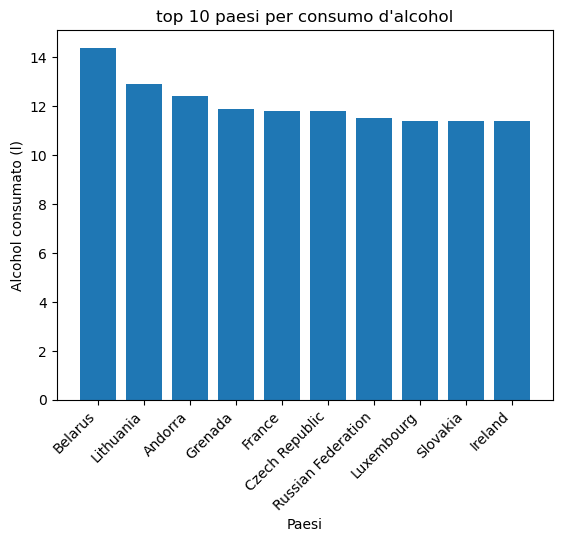

In [85]:
# Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

plt.bar(ordered["country"].head(10), ordered["total_litres_of_pure_alcohol"].head(10))

plt.title("top 10 paesi per consumo d'alcohol")
plt.xlabel("Paesi")
plt.ylabel("Alcohol consumato (l)")
plt.xticks(rotation=45, ha="right", va="top")

plt.show()

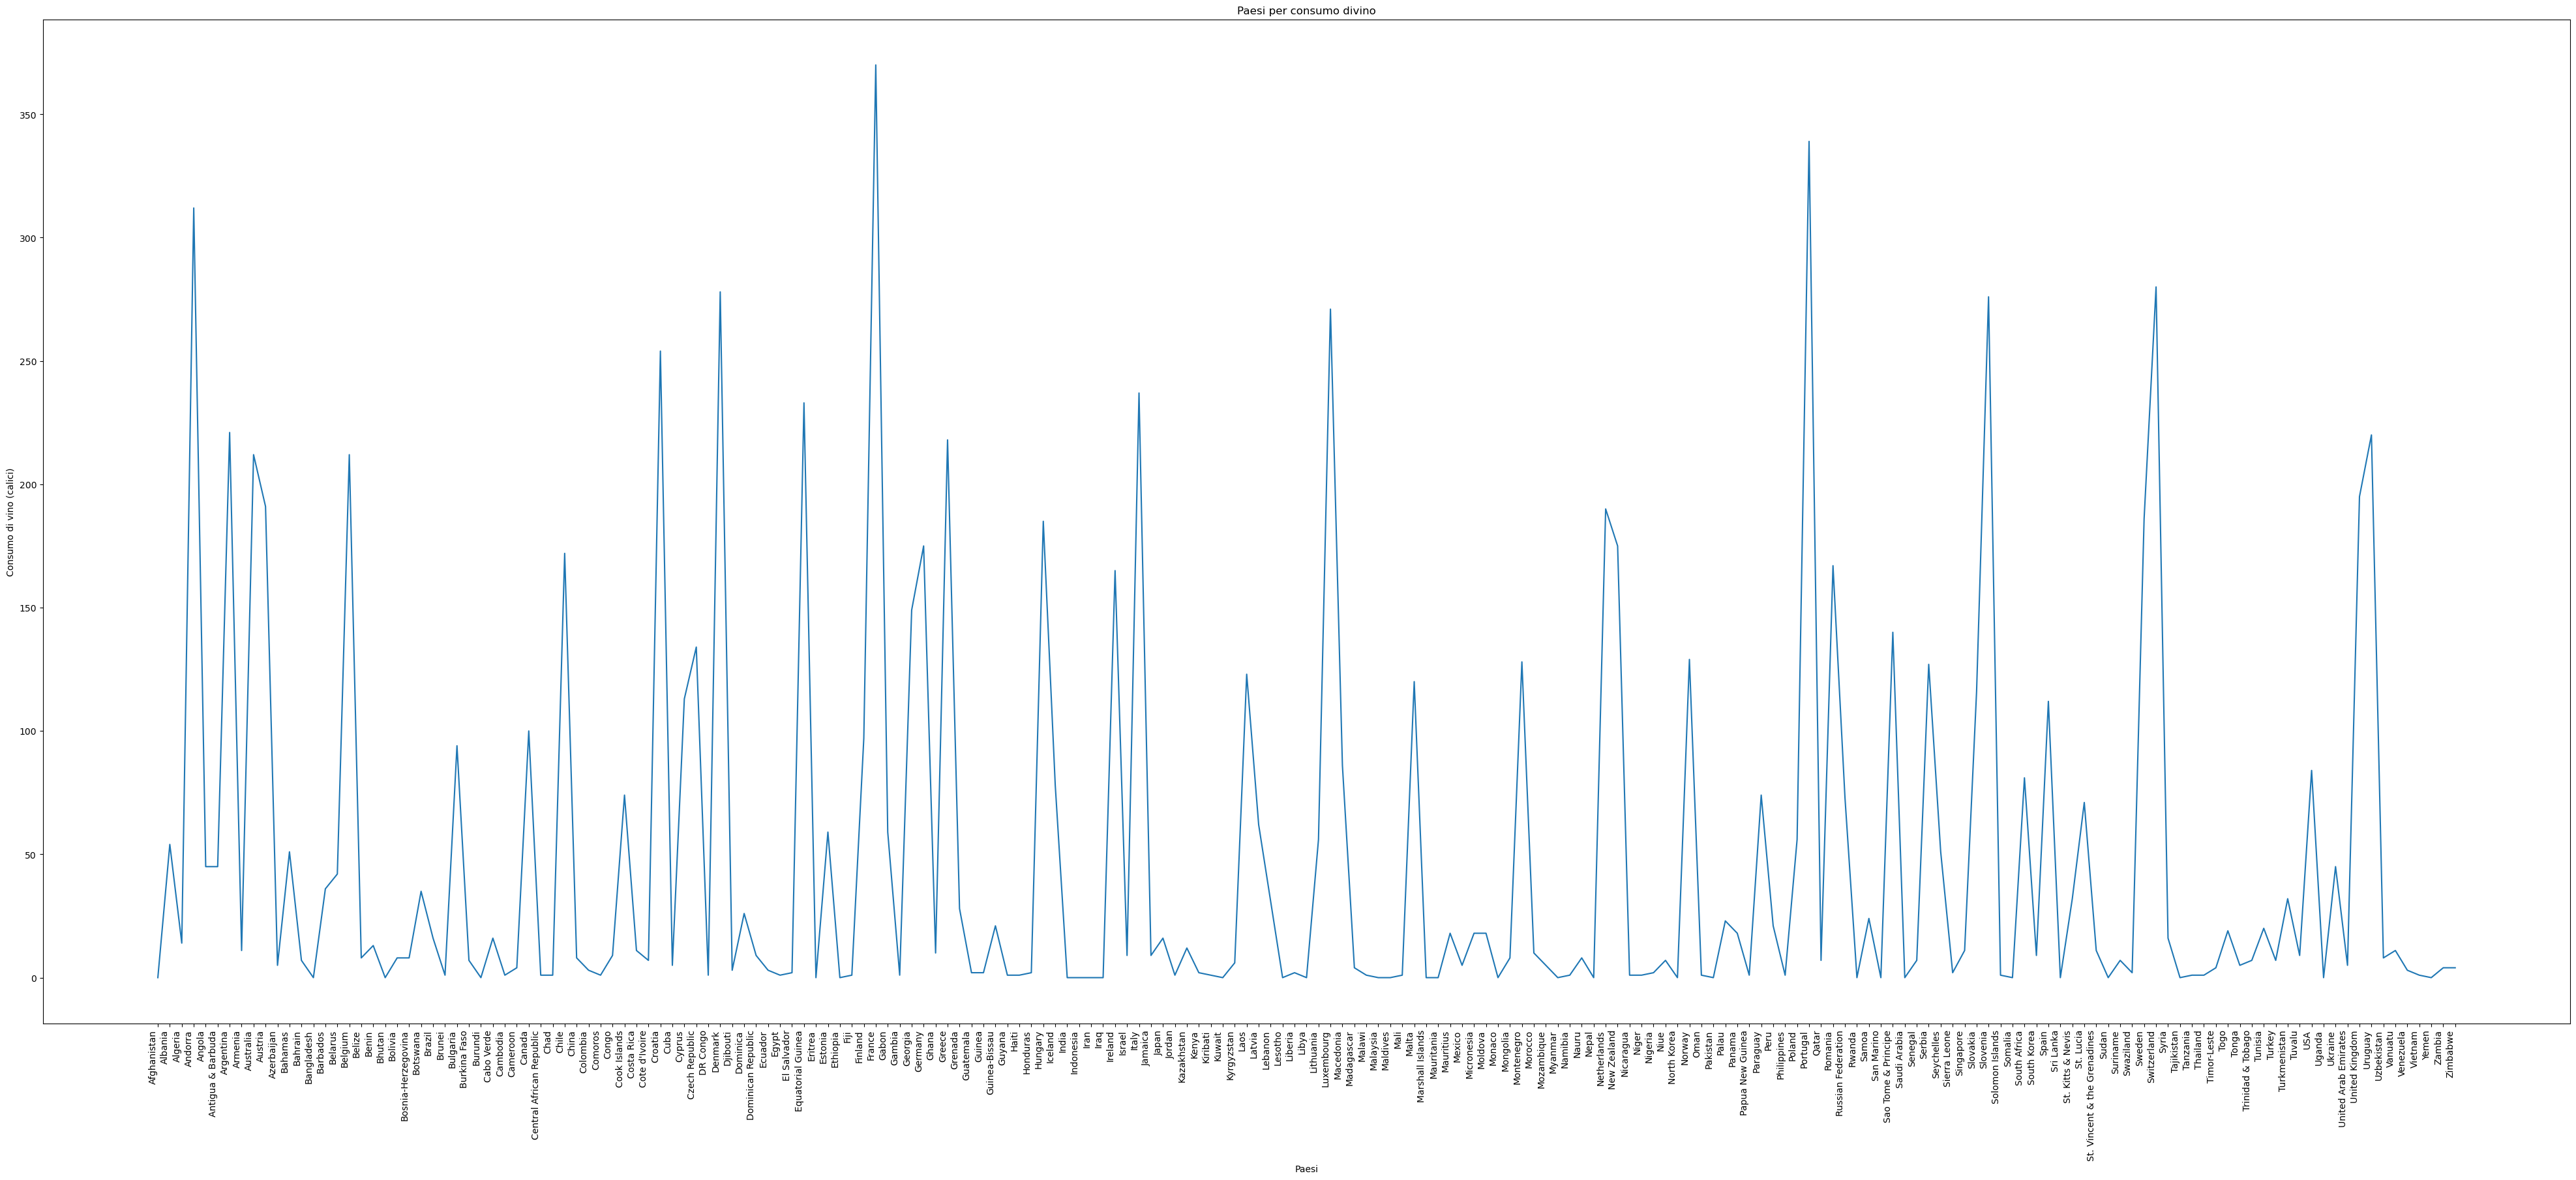

In [86]:
# Crea un line plot con wine_servings ordinato per paese (usa sort_values)
tmp = df.sort_values(by="country", ascending=True)

plt.figure(figsize=(50, 20))

plt.plot(tmp["country"], tmp["wine_servings"])

plt.title("Paesi per consumo divino")
plt.xlabel("Paesi")
plt.ylabel("Consumo di vino (calici)")
plt.xticks(rotation=90, ha="right", va="top")

plt.show()


## 2. Analisi offerte di lavoro

### Esegui un’analisi esplorativa focalizzata sui lavori nel campo dei dati in ciascun paese.
### Analizza i seguenti aspetti per ogni paese:

### - Lo stipendio medio annuale (salary_year_avg)
### - Il numero totale di offerte di lavoro (job count)
### - L’intervallo degli stipendi: valore minimo e massimo (min / max)

### Rappresenta graficamente lo stipendio medio (salary_year_avg) per job_title_short usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [87]:
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df.info()
df[df["salary_year_avg"].notna()]

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
28,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",via Ai-Jobs.net,Full-time,False,Costa Rica,2023-08-01 13:37:57,False,False,Costa Rica,year,109500.0,NaN,Netskope,"['gdpr', 'excel']","{'analyst_tools': ['excel'], 'libraries': ['gd..."
77,Data Engineer,Data Engineer,"Arlington, VA",via LinkedIn,Full-time,False,Sudan,2023-06-26 14:22:54,False,False,Sudan,year,140000.0,NaN,Intelletec,"['mongodb', 'mongodb', 'python', 'r', 'sql', '...","{'analyst_tools': ['tableau'], 'cloud': ['orac..."
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"['sql', 'python']","{'programming': ['sql', 'python']}"
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,NaN,TikTok,"['sql', 'r', 'python', 'express']","{'programming': ['sql', 'r', 'python'], 'webfr..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"['python', 'r', 'alteryx', 'tableau']","{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785624,Data Engineer,Data Analytics Engineer (Hybrid),"Mt Prospect, IL",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-08-31 06:02:16,False,True,United States,year,139216.0,NaN,Bosch Group,"['go', 'python', 'r', 'sql', 'oracle', 'window...","{'analyst_tools': ['alteryx', 'power bi', 'tab..."
785641,Data Engineer,Data Engineer,"New York, NY",via Dice,Full-time,False,Georgia,2023-01-04 16:36:07,True,False,United States,year,150000.0,NaN,"Engage Partners, Inc.",NaN,NaN
785648,Data Scientist,Director Data Scientist - Commercial Platforms...,"Pleasant Hill, CA",via Ai-Jobs.net,Full-time,False,"California, United States",2023-04-12 06:02:51,False,True,United States,year,221875.0,NaN,84.51°,"['python', 'azure', 'snowflake', 'spark']","{'cloud': ['azure', 'snowflake'], 'libraries':..."
785682,Data Scientist,Data Scientist für datengetriebene Entwicklung...,"Reutlingen, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-03-04 06:16:08,False,False,Germany,year,157500.0,NaN,Bosch Group,"['python', 'hadoop', 'spark', 'airflow', 'kube...","{'libraries': ['hadoop', 'spark', 'airflow'], ..."


In [88]:
# pulizia dataset

cln_salary_year = df.dropna(subset=["salary_year_avg"])
cln_salary_year.head(5)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
28,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",via Ai-Jobs.net,Full-time,False,Costa Rica,2023-08-01 13:37:57,False,False,Costa Rica,year,109500.0,NaN,Netskope,"['gdpr', 'excel']","{'analyst_tools': ['excel'], 'libraries': ['gd..."
77,Data Engineer,Data Engineer,"Arlington, VA",via LinkedIn,Full-time,False,Sudan,2023-06-26 14:22:54,False,False,Sudan,year,140000.0,NaN,Intelletec,"['mongodb', 'mongodb', 'python', 'r', 'sql', '...","{'analyst_tools': ['tableau'], 'cloud': ['orac..."
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"['sql', 'python']","{'programming': ['sql', 'python']}"
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,NaN,TikTok,"['sql', 'r', 'python', 'express']","{'programming': ['sql', 'r', 'python'], 'webfr..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"['python', 'r', 'alteryx', 'tableau']","{'analyst_tools': ['alteryx', 'tableau'], 'pro..."


In [89]:
# Lo stipendio medio annuale (salary_year_avg)

cln_salary_year.groupby("job_country")["salary_year_avg"].mean()

job_country
Albania        79472.500000
Algeria        44550.000000
Argentina     105212.343750
Armenia        78757.000000
Australia     118987.574324
                  ...      
Uruguay        69333.333333
Uzbekistan     30750.000000
Vietnam        90927.236364
Zambia         90670.000000
Zimbabwe       67056.666667
Name: salary_year_avg, Length: 108, dtype: float64

In [90]:
# Il numero totale di offerte di lavoro (job count)

df.groupby("job_country")["salary_year_avg"].count()

job_country
Afghanistan     0
Albania         5
Algeria         2
Angola          0
Argentina      32
               ..
Venezuela       0
Vietnam        55
Yemen           0
Zambia          1
Zimbabwe        3
Name: salary_year_avg, Length: 160, dtype: int64

In [91]:
# L’intervallo degli stipendi: valore minimo e massimo (min / max)

cln_salary_year.groupby("job_country")["salary_year_avg"].agg(["min", "max"])

,min,max
job_country,,
Albania,43200.0,157500.0
Algeria,44100.0,45000.0
Argentina,45000.0,222000.0
Armenia,45000.0,128682.0
Australia,20000.0,257500.0
...,...,...
Uruguay,50000.0,100500.0
Uzbekistan,30750.0,30750.0
Vietnam,28000.0,200000.0


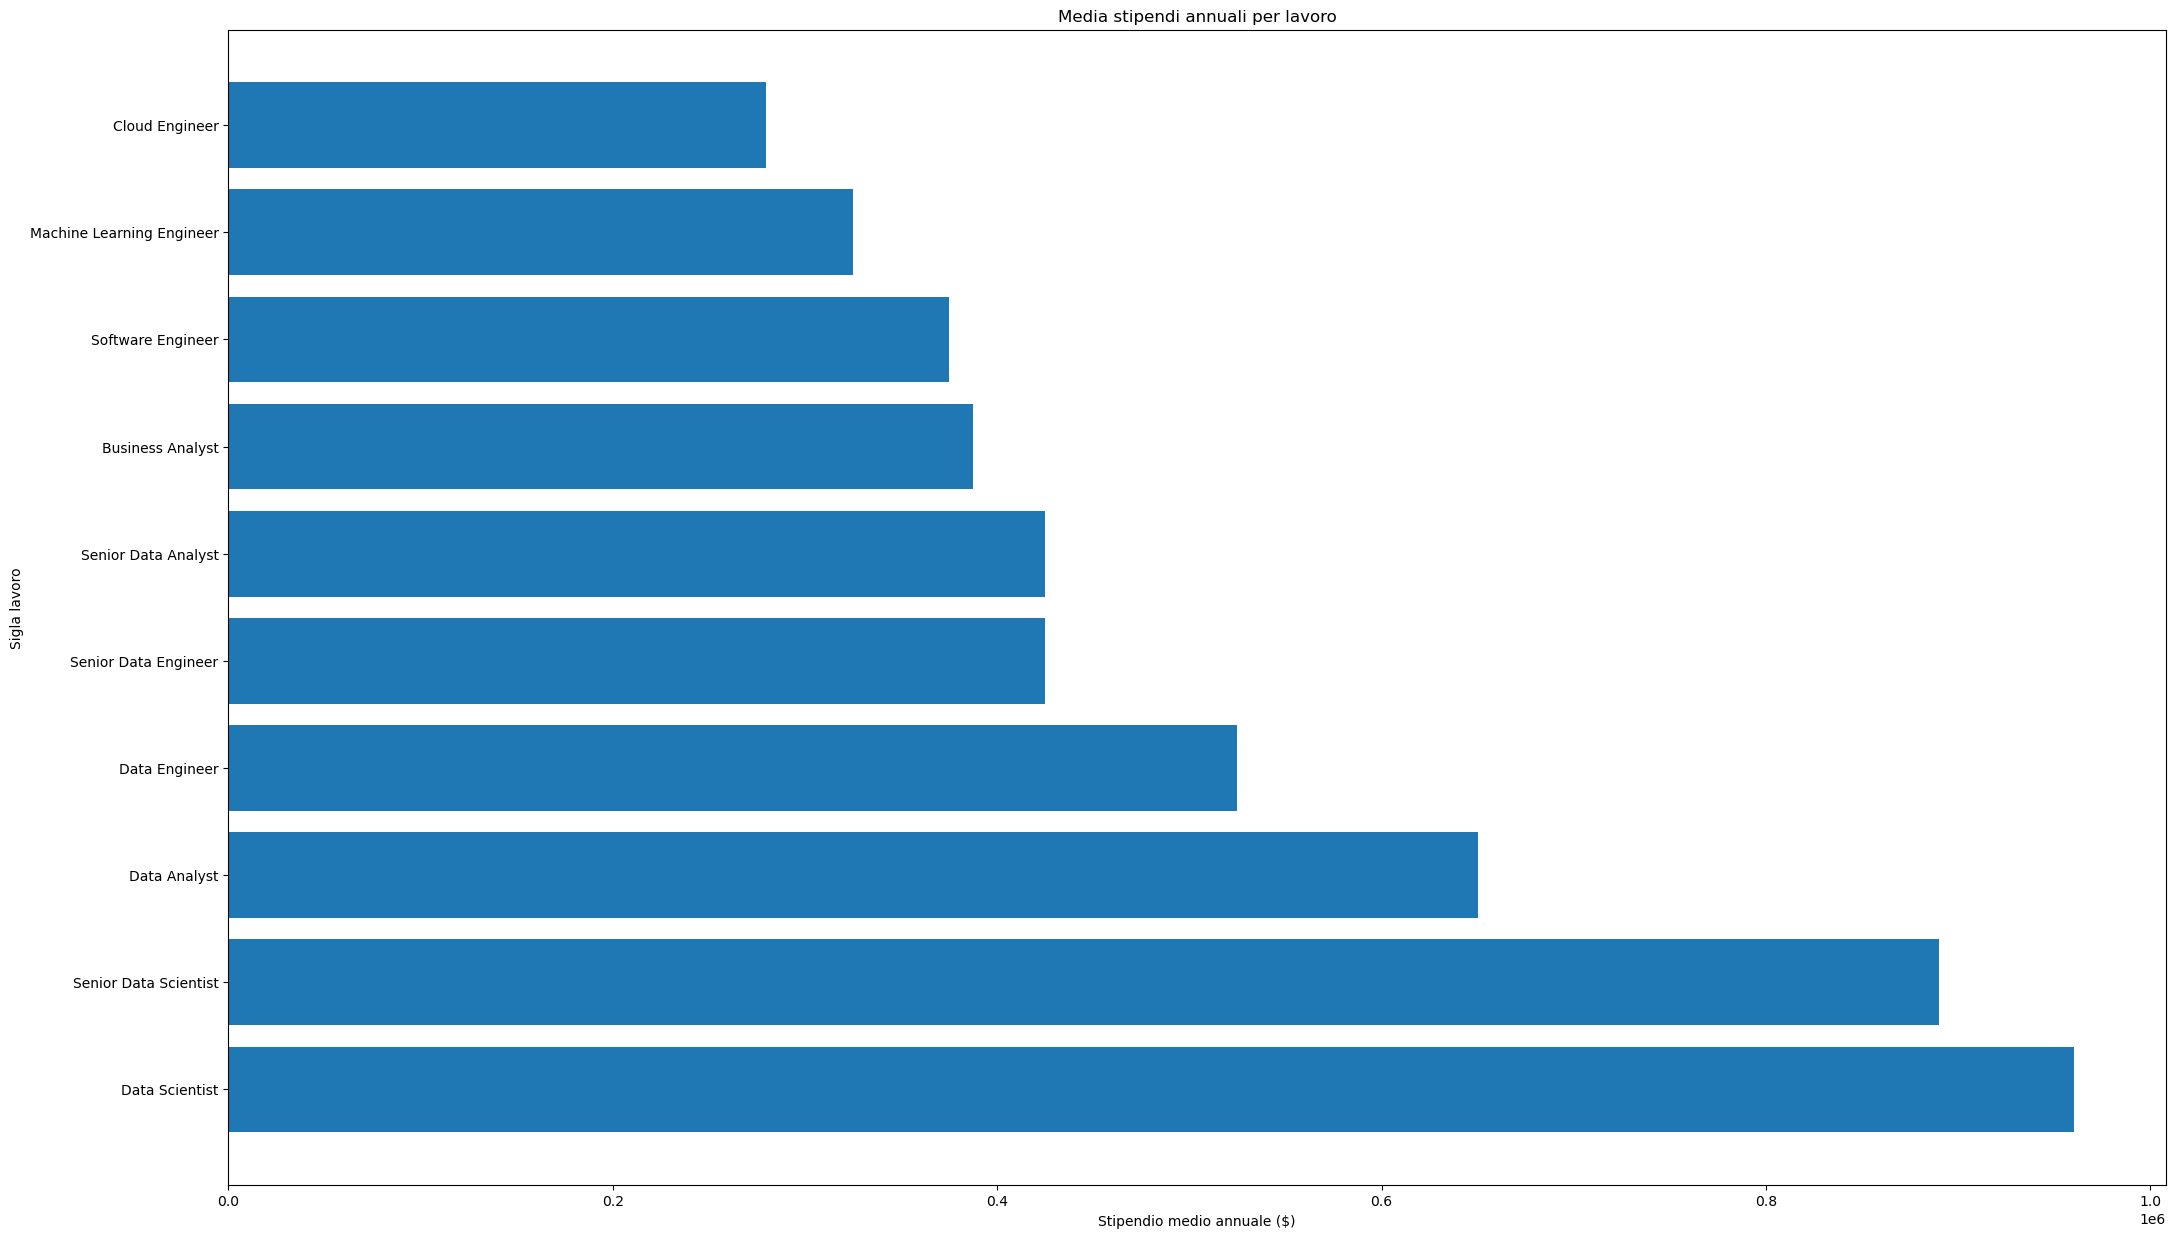

In [124]:
# Rappresenta graficamente lo stipendio medio (salary_year_avg) per job_title_short usando un grafico a barre orizzontali. 
# Ordina i dati dallo stipendio più alto al più basso. 
# Includi un titolo e le etichette per gli assi x e y.

plt.figure(figsize=(25,15))

tmp = cln_salary_year.sort_values(by="salary_year_avg", ascending=False)

plt.barh(tmp["job_title_short"], tmp['salary_year_avg'])
plt.title("Media stipendi annuali per lavoro")
plt.xlabel("Stipendio medio annuale ($)")
plt.ylabel("Sigla lavoro")
plt.show()

## 3. Analisi vendite (dataset tips) 

### Esegui un’analisi esplorativa focalizzata sulle vendite giornaliere.
### Analizza i seguenti aspetti per ogni giorno (day):

### - Il conto medio (total_bill)

### - Il numero totale di osservazioni (conteggio delle righe)

### - Il valore minimo e massimo del conto (total_bill → min / max)

### - Crea una nuova colonna conto_per_persona che sia: total_bill / size

### - Trova il giorno con il conto medio più alto

### Rappresenta graficamente il conto medio (total_bill) per giorno usando un grafico a barre.
### Ordina i dati dal valore più alto al più basso.
### Aggiungi titolo ed etichette agli assi.

In [96]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [97]:
# Il conto medio (total_bill)

df.groupby("day")["total_bill"].mean()

day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742
Name: total_bill, dtype: float64

In [99]:
# Il numero totale di osservazioni (conteggio delle righe)

df.groupby("day")["tip"].count()

day
Fri     19
Sat     87
Sun     76
Thur    62
Name: tip, dtype: int64

In [100]:
# Il valore minimo e massimo del conto (total_bill → min / max)

df.groupby("day")["total_bill"].agg(["min", "max"])

,min,max
day,,
Fri,5.75,40.17
Sat,3.07,50.81
Sun,7.25,48.17
Thur,7.51,43.11


In [104]:
# Crea una nuova colonna conto_per_persona che sia: total_bill / size
df["conto_per_persona"] = df["total_bill"]/df["size"]
df.groupby("day")["conto_per_persona"].mean()


day
Fri     8.132851
Sat     8.187232
Sun     7.864024
Thur    7.423368
Name: conto_per_persona, dtype: float64

In [121]:
# Trova il giorno con il conto medio più alto

df.groupby("day")["total_bill"].mean().idxmax()

#oppure mi salvo questo in una variabile, faccio var.index[np.argmax(var.values)]



'Sun'

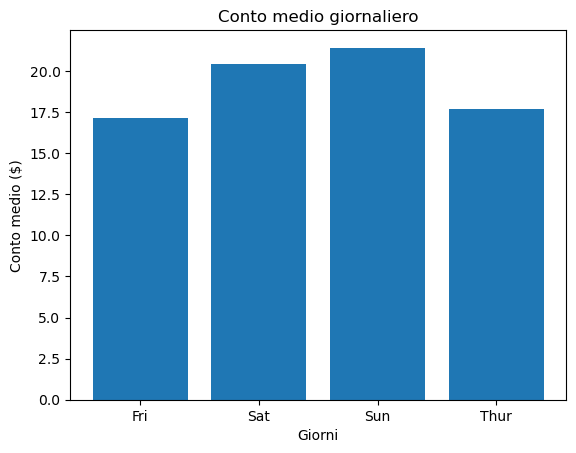

In [123]:
# Rappresenta graficamente il conto medio (total_bill) per giorno usando un grafico a barre.
# Ordina i dati dal valore più alto al più basso.
# Aggiungi titolo ed etichette agli assi.

tmp = df.groupby("day")["total_bill"].mean()


plt.bar(tmp.index, tmp.values)
plt.title("Conto medio giornaliero")
plt.xlabel("Giorni")
plt.ylabel("Conto medio ($)")

plt.show()

